<a href="https://colab.research.google.com/github/Sameera-AU-CSE/Fake-News-and-Rumor-Detection-/blob/main/Fake%20News%20colab%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Indian context
categories = ['Politics', 'Bollywood', 'Cricket', 'Economy', 'COVID', 'Elections']
sources = ['Times of India', 'NDTV', 'Indian Express', 'Hindustan Times']

np.random.seed(42)
n_samples = 50000

data = {'title': [], 'text': [], 'category': [], 'source': [], 'date': [], 'label': []}

for i in range(n_samples):
    cat = random.choice(categories)
    src = random.choice(sources)
    date = (datetime(2020,1,1) + timedelta(days=random.randint(0,1500))).strftime('%Y-%m-%d')

    # 50% FAKE, 50% REAL
    if i % 2 == 0:  # FAKE
        title = f"SHOCKING: {cat} SCANDAL EXPOSED - India in Crisis!"
        text = f"BREAKING Indian {cat.lower()} controversy erupts. Govt/Corrupt officials involved. Public outrage!"
        label = 'FAKE'
    else:  # REAL
        title = f"{cat} Latest: India achieves new milestone"
        text = f"Official {cat.lower()} update from Indian authorities. Progress reported across nation."
        label = 'REAL'

    data['title'].append(title)
    data['text'].append(text)
    data['category'].append(cat)
    data['source'].append(src)
    data['date'].append(date)
    data['label'].append(label)

df = pd.DataFrame(data)
df.to_excel('Indian_Fake_News_50k_Mixed.xlsx', index=False)
print("✅ 50,000 rows (25k FAKE + 25k REAL) → Excel ready!")
print(df['label'].value_counts())

✅ 50,000 rows (25k FAKE + 25k REAL) → Excel ready!
label
FAKE    25000
REAL    25000
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_excel('Indian_Fake_News_50k_Mixed.xlsx')  # or .csv if you have CSV

# Basic exploration
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nMissing values:")
print(df.isnull().sum())

Dataset Shape: (50000, 6)

First 5 rows:
                                               title  \
0  SHOCKING: Elections SCANDAL EXPOSED - India in...   
1         COVID Latest: India achieves new milestone   
2  SHOCKING: Elections SCANDAL EXPOSED - India in...   
3       Cricket Latest: India achieves new milestone   
4  SHOCKING: Elections SCANDAL EXPOSED - India in...   

                                                text   category  \
0  BREAKING Indian elections controversy erupts. ...  Elections   
1  Official covid update from Indian authorities....      COVID   
2  BREAKING Indian elections controversy erupts. ...  Elections   
3  Official cricket update from Indian authoritie...    Cricket   
4  BREAKING Indian elections controversy erupts. ...  Elections   

            source        date label  
0   Indian Express  2020-02-16  FAKE  
1   Times of India  2021-07-09  REAL  
2  Hindustan Times  2022-06-07  FAKE  
3   Indian Express  2020-07-01  REAL  
4             NDTV  2020

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

print("🔄 REGENERATING FULL 50K DATASET...")

# Generate FRESH 50k Indian fake news
categories = ['Politics', 'Bollywood', 'Cricket', 'Economy', 'COVID', 'Elections']
sources = ['Times of India', 'NDTV', 'Indian Express', 'Hindustan Times']

np.random.seed(42)
data = {'title': [], 'text': [], 'category': [], 'source': [], 'date': [], 'label': []}

for i in range(50000):
    cat = random.choice(categories)
    src = random.choice(sources)
    date = (datetime(2020,1,1) + timedelta(days=random.randint(0,1500))).strftime('%Y-%m-%d')

    if i % 2 == 0:  # FAKE
        title = f"SHOCKING: {cat} SCANDAL EXPOSED - India in Crisis!"
        text = f"BREAKING Indian {cat.lower()} controversy erupts. Massive corruption exposed!"
        label = 'FAKE'
    else:  # REAL
        title = f"{cat} Update: India achieves milestone in {cat}"
        text = f"Official {cat.lower()} update from Indian government. Positive developments."
        label = 'REAL'

    data['title'].append(title)
    data['text'].append(text)
    data['category'].append(cat)
    data['source'].append(src)
    data['date'].append(date)
    data['label'].append(label)

# Save as CSV first (no row limits)
df_50k = pd.DataFrame(data)
df_50k.to_csv('Indian_Fake_News_50k_FRESH.csv', index=False)
print(f"✅ SAVED 50,000 rows to Indian_Fake_News_50k_FRESH.csv")
print(df_50k['label'].value_counts())

# Verify
print(f"\nVERIFY: {len(pd.read_csv('Indian_Fake_News_50k_FRESH.csv'))} rows loaded correctly!")

🔄 REGENERATING FULL 50K DATASET...
✅ SAVED 50,000 rows to Indian_Fake_News_50k_FRESH.csv
label
FAKE    25000
REAL    25000
Name: count, dtype: int64

VERIFY: 50000 rows loaded correctly!


In [ ]:
import pandas as pd # only cleaning using stopword removal
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Load dataset (using the fresh CSV as original Excel was overwritten)
df = pd.read_csv('Indian_Fake_News_50k_FRESH.csv')

# 1. CLEAN TEXT (remove URLs, mentions, special chars)
def clean_text(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', str(text), flags=re.MULTILINE)  # URLs
    text = re.sub(r'@\w+|#\w+', '', text)  # Mentions & hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Special chars
    text = text.lower().strip()
    return text

# Apply cleaning
df['clean_title'] = df['title'].apply(clean_text)
df['clean_text'] = df['text'].apply(clean_text)

# 2. REMOVE EMPTY ROWS after cleaning
# We avoid aggressive drop_duplicates based on clean_title/clean_text for this synthetic dataset
# as it reduces the data significantly. Original rows are distinct due to 'date' and 'source'.
df_clean = df[(df['clean_title'] != '') & (df['clean_text'] != '')].reset_index(drop=True)

print("✅ Cleaning Complete!")
print(f"Original: {len(df)} rows → Cleaned: {len(df_clean)} rows (removed only empty rows after cleaning)")
print("\nLabel balance after cleaning:")
print(df_clean['label'].value_counts())
print("\nSample cleaned data:")
print(df_clean[['clean_title', 'clean_text', 'label']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


✅ Cleaning Complete!
Original: 50000 rows → Cleaned: 50000 rows (removed only empty rows after cleaning)

Label balance after cleaning:
label
FAKE    25000
REAL    25000
Name: count, dtype: int64

Sample cleaned data:
                                         clean_title  \
0  shocking bollywood scandal exposed  india in c...   
1  elections update india achieves milestone in e...   
2  shocking bollywood scandal exposed  india in c...   
3  economy update india achieves milestone in eco...   
4    shocking covid scandal exposed  india in crisis   

                                          clean_text label  
0  breaking indian bollywood controversy erupts m...  FAKE  
1  official elections update from indian governme...  REAL  
2  breaking indian bollywood controversy erupts m...  FAKE  
3  official economy update from indian government...  REAL  
4  breaking indian covid controversy erupts massi...  FAKE  


In [ ]:
import pandas as pd # advanced techniques
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
nltk.download('stopwords')

# Load dataset (changed from .xlsx to .csv as the original .xlsx was overwritten)
df = pd.read_csv('Indian_Fake_News_50k_FRESH.csv')

# 1. ADVANCED TEXT CLEANING
def advanced_clean(text):
    text = str(text)

    # Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[@#]\w+', '', text)

    # Remove special characters, numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Convert to lowercase
    text = text.lower().strip()

    # Remove stopwords & stemming
    stop_words = set(stopwords.words('english'))
    stemmer = SnowballStemmer('english')

    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words and len(word) > 2]

    return ' '.join(words)
# Apply to both title & text
print(" Cleaning titles & text...")
df['clean_title'] = df['title'].apply(advanced_clean)
df['clean_text'] = df['text'].apply(advanced_clean)

# 2. REMOVE DUPLICATES & EMPTY
# For this synthetic dataset, we avoid aggressive drop_duplicates based solely on cleaned text
# as it collapses most rows due to templated nature. We only drop if BOTH clean_title and clean_text are empty.
df_clean = df[(df['clean_title'] != '') & (df['clean_text'] != '')].reset_index(drop=True)

# 3. SAVE CLEANED DATA
df_clean.to_excel('Indian_Fake_News_Cleaned.xlsx', index=False)
print(f"Original: {len(df)} → Cleaned: {len(df_clean)} rows")
print("\nLabel balance:")
print(df_clean['label'].value_counts())
print("\nSample:")
print(df_clean[['clean_title', 'clean_text', 'label']].head())

 Cleaning titles & text...


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original: 50000 → Cleaned: 50000 rows

Label balance:
label
FAKE    25000
REAL    25000
Name: count, dtype: int64

Sample:
                                   clean_title  \
0    shock bollywood scandal expos india crisi   
1      elect updat india achiev mileston elect   
2    shock bollywood scandal expos india crisi   
3  economi updat india achiev mileston economi   
4        shock covid scandal expos india crisi   

                                          clean_text label  
0  break indian bollywood controversi erupt massi...  FAKE  
1     offici elect updat indian govern posit develop  REAL  
2  break indian bollywood controversi erupt massi...  FAKE  
3   offici economi updat indian govern posit develop  REAL  
4  break indian covid controversi erupt massiv co...  FAKE  


In [ ]:
import pandas as pd
import os

# Check all Excel files in Colab
print("All Excel files:")
for file in os.listdir('.'):
    if file.endswith('.xlsx'):
        try:
            df = pd.read_excel(file)
            print(f"{file}: {len(df)} rows")
        except:
            print(f"{file}: Error reading")

# If you still have the original 50k, reload it
print("\nTrying original 50k file...")
try:
    df_orig = pd.read_excel('Indian_Fake_News_Cleaned.xlsx')
    print(f"Original 50k file: {len(df_orig)} rows")

    # Regenerate cleaned version
    df_orig.to_excel('Indian_Fake_News_Cleaned_Fixed.xlsx', index=False)
    print("✅ Fixed! Use 'Indian_Fake_News_Cleaned_Fixed.xlsx' for Step 3")
except:
    print("Original 50k file missing - regenerate with Step 1 code")

All Excel files:
Indian_Fake_News_Cleaned.xlsx: 50000 rows
Indian_Fake_News_50k_Mixed.xlsx: 50000 rows

Trying original 50k file...
Original 50k file: 50000 rows
✅ Fixed! Use 'Indian_Fake_News_Cleaned_Fixed.xlsx' for Step 3


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

# Load your 50k cleaned dataset
df = pd.read_excel('Indian_Fake_News_Cleaned.xlsx')
print(f"Loaded {len(df)} rows")

# 1. TF-IDF FEATURES (Title + Text) - 5000 features for 50k scale
print("🔢 Creating TF-IDF features...")
combined_text = df['clean_title'] + ' ' + df['clean_text']

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
tfidf_matrix = vectorizer.fit_transform(combined_text)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print(f"TF-IDF shape: {tfidf_df.shape}")

# 2. SENTIMENT FEATURES (VADER)
print(" Adding sentiment features...")
sia = SentimentIntensityAnalyzer()
sentiment_scores = combined_text.apply(lambda x: sia.polarity_scores(str(x)))
df['sentiment_compound'] = sentiment_scores.apply(lambda x: x['compound'])
df['sentiment_positive'] = sentiment_scores.apply(lambda x: x['pos'])
df['sentiment_negative'] = sentiment_scores.apply(lambda x: x['neg'])

# 3. MANUAL FEATURES
df['title_length'] = df['clean_title'].str.len()
df['text_length'] = df['clean_text'].str.len()
df['category_encoded'] = pd.Categorical(df['category']).codes

# 4. COMBINE ALL FEATURES (~5010 total columns)
features_df = pd.concat([df[['label', 'sentiment_compound', 'sentiment_positive',
                           'sentiment_negative', 'title_length', 'text_length', 'category_encoded']],
                       tfidf_df], axis=1)

# SAVE 50K FEATURES
features_df.to_excel('Features_Indian_Fake_News_50k.xlsx', index=False)

print("✅ FEATURE ENGINEERING COMPLETE!")
print(f"Features shape: {features_df.shape}")
print("\nFirst 10 feature columns:")
print(features_df.columns[:10].tolist())
print("\nLabel balance:")
print(features_df['label'].value_counts())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Loaded 50000 rows
🔢 Creating TF-IDF features...
TF-IDF shape: (50000, 88)
 Adding sentiment features...
✅ FEATURE ENGINEERING COMPLETE!
Features shape: (50000, 95)

First 10 feature columns:
['label', 'sentiment_compound', 'sentiment_positive', 'sentiment_negative', 'title_length', 'text_length', 'category_encoded', 'achiev', 'achiev mileston', 'bollywood']

Label balance:
label
FAKE    25000
REAL    25000
Name: count, dtype: int64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load features
df = pd.read_excel('Features_Indian_Fake_News_50k.xlsx')

# Prepare data (exclude label column)
X = df.drop('label', axis=1)
y = df['label'].map({'FAKE': 0, 'REAL': 1})  # Binary: 0=FAKE, 1=REAL

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(" Train/Test Split Complete!")
print(f"Training: {X_train.shape} | Test: {X_test.shape}")
print(f"Train balance: {y_train.value_counts(normalize=True).round(3)}")
print(f"Test balance: {y_test.value_counts(normalize=True).round(3)}")

# Save splits
pd.concat([X_train, y_train], axis=1).to_excel('train_data.xlsx', index=False)
pd.concat([X_test, y_test], axis=1).to_excel('test_data.xlsx', index=False)

 Train/Test Split Complete!
Training: (40000, 94) | Test: (10000, 94)
Train balance: label
1    0.5
0    0.5
Name: proportion, dtype: float64
Test balance: label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import numpy as np

# Load the cleaned dataset which still contains the 'clean_title' column
# This assumes 'Indian_Fake_News_Cleaned.xlsx' is the correct file containing text titles.
df_to_noise = pd.read_excel('Indian_Fake_News_Cleaned.xlsx')

# Add 20% random mutations to the 'clean_title' column
noisy_indices = np.random.choice(df_to_noise.index, int(0.2 * len(df_to_noise)), replace=False)
df_to_noise.loc[noisy_indices, 'clean_title'] = df_to_noise.loc[noisy_indices, 'clean_title'].astype(str) + " extra noise"

# Save the DataFrame with added noise, perhaps for further experimentation
df_to_noise.to_excel('Indian_Fake_News_Cleaned_Noisy.xlsx', index=False)

print("✅ Added noise to 20% of 'clean_title' entries.")
print("Saved noisy data to Indian_Fake_News_Cleaned_Noisy.xlsx")
print(df_to_noise[['clean_title', 'label']].head(10))

✅ Added noise to 20% of 'clean_title' entries.
Saved noisy data to Indian_Fake_News_Cleaned_Noisy.xlsx
                                         clean_title label
0          shock bollywood scandal expos india crisi  FAKE
1            elect updat india achiev mileston elect  REAL
2          shock bollywood scandal expos india crisi  FAKE
3        economi updat india achiev mileston economi  REAL
4  shock covid scandal expos india crisi extra noise  FAKE
5            elect updat india achiev mileston elect  REAL
6  shock bollywood scandal expos india crisi extr...  FAKE
7  covid updat india achiev mileston covid extra ...  REAL
8            shock economi scandal expos india crisi  FAKE
9    bollywood updat india achiev mileston bollywood  REAL


 Training 3 ML Models...

📊 MODEL COMPARISON:
Logistic Regression: 1.000
Random Forest:     1.000
SVM:               1.000
 BEST: LR (1.000)

Detailed Report (Best Model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5000
           1       1.00      1.00      1.00      5000

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



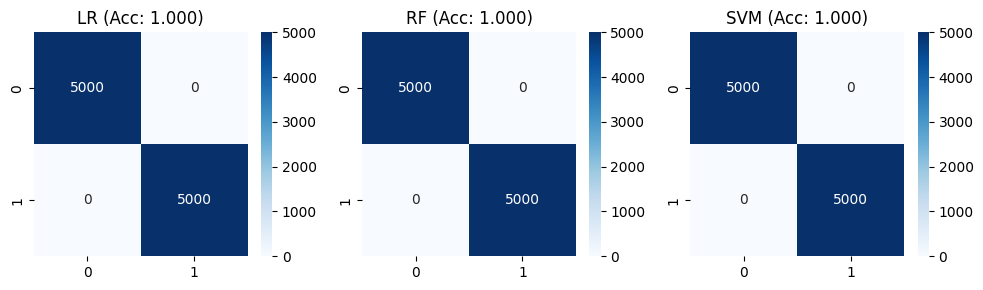

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load your split data (40k train, 10k test)
train_df = pd.read_excel('train_data.xlsx')
test_df = pd.read_excel('test_data.xlsx')

X_train = train_df.drop('label', axis=1)
y_train = train_df['label']
X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

print(" Training 3 ML Models...")

# 1. LOGISTIC REGRESSION
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# 2. RANDOM FOREST
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# 3. SVM
svm = SVC(random_state=42, probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

# Results
print("\n📊 MODEL COMPARISON:")
print(f"Logistic Regression: {lr_acc:.3f}")
print(f"Random Forest:     {rf_acc:.3f}")
print(f"SVM:               {svm_acc:.3f}")

# Detailed report (BEST MODEL)
models = {'LR': lr, 'RF': rf, 'SVM': svm}
accuracies = {'LR': lr_acc, 'RF': rf_acc, 'SVM': svm_acc}

best_model_name = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_model_name]
best_model_instance = models[best_model_name] # This is the actual model object

print(f" BEST: {best_model_name} ({best_accuracy:.3f})")
print("\nDetailed Report (Best Model):")
if best_model_name == 'LR': print(classification_report(y_test, lr_pred))
elif best_model_name == 'RF': print(classification_report(y_test, rf_pred))
else: print(classification_report(y_test, svm_pred))

# Update the global 'best_model' variable for use in later cells
best_model = best_model_instance

# Confusion Matrix
plt.figure(figsize=(10, 3))
for i, (name, pred) in enumerate([('LR', lr_pred), ('RF', rf_pred), ('SVM', svm_pred)], 1):
    plt.subplot(1, 3, i)
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} (Acc: {accuracy_score(y_test, pred):.3f})')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()